In [1]:
import os,pickle,re

import numpy as np
import pandas as pd
from sklearn.metrics import f1_score,make_scorer,precision_score,recall_score
import shap

from project_package.visualization import Model_Visualizer
from project_package import evaluation,modeling

In [2]:
# choose to test either full version or lite version
use_lite_version = False
if use_lite_version:
    base_directory = 'supervised_lite'
else:
    base_directory = 'supervised'

# setting
recalculate_evaluation = False

#### Problem 1: Classification (booking completion vs cancellation)

In [6]:
files = os.listdir(base_directory)

file = [item for item in files if 'target_completed_.pkl' in item][-1]

model_path = os.path.join(base_directory, file)

with open(model_path, "rb") as f:
    model = pickle.load(f)
model

Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num',
                                                  SimpleImputer(strategy='median'),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x0000026F606A2550>),
                                                 ('cat',
                                                  Pipeline(steps=[('imp',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ord',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x0000026F606B7190>)])),
                ('clf',
                 RandomForestClassifier(class_weight='balanced', max_depth=11,
                                        min_samples_leaf=3, n_estimators=300,
                                        n_jobs=-1, random_state=42))])

Load the train and test data

In [4]:
split_df = pd.read_csv(os.path.join(base_directory, 'split_assignments_classification.csv'),
                       on_bad_lines='skip'
                       )

if use_lite_version:
    model_data =pd.read_csv('ncr_ride_bookings_with_weather_filled_scaled_short___target_completed___top20_s30.csv')
else:
    model_data =pd.read_csv('ncr_ride_bookings_with_weather_filled_scaled_short.csv')

In [5]:
if use_lite_version:
    # train data
    train_split = split_df.loc[split_df.split=='train'][['Booking ID','Customer ID']]
    train_data = model_data.merge(train_split,on=['Booking ID','Customer ID'])
    y_train = train_data['_target_completed_']
    train_data = modeling.drop_unnecessary_cols(train_data)
    # validation data
    test_split = split_df.loc[split_df.split=='valid'][['Booking ID','Customer ID']]
    test_data = model_data.merge(test_split,on=['Booking ID','Customer ID'])
    y_test = test_data['_target_completed_']
    test_data = modeling.drop_unnecessary_cols(test_data)
else:
    # train data
    train_split = split_df.loc[split_df.split=='train'][['Booking ID','Customer ID']]
    train_data = model_data.merge(train_split,on=['Booking ID','Customer ID'])
    train_data = modeling.make_binary_target(train_data)[0]
    y_train = train_data['_target_completed_']
    train_data = modeling.drop_unnecessary_cols(train_data)
    # validation data
    test_split = split_df.loc[split_df.split=='valid'][['Booking ID','Customer ID']]
    test_data = model_data.merge(test_split,on=['Booking ID','Customer ID'])
    test_data = modeling.make_binary_target(test_data)[0]
    y_test = test_data['_target_completed_']
    test_data = modeling.drop_unnecessary_cols(test_data)



In [7]:
prediction_df = pd.read_csv(f'{base_directory}/cls_best_rf_preds.csv')

# check model metric score
print('---------on training dataset--------------')
print('precision from model:',precision_score(y_train,model.predict(train_data)))
print('precision from model(macro):',precision_score(y_train,model.predict(train_data),average='macro'))
print()
print('recall from model:',recall_score(y_train,model.predict(train_data)))
print('recall from model(macro):',recall_score(y_train,model.predict(train_data),average='macro'))

print()
print('---------on test dataset--------------')
print('precision from model:',precision_score(y_test,model.predict(test_data)))
print('precision from model(macro):',precision_score(y_test,model.predict(test_data),average='macro'))
print('precision from file:',precision_score(prediction_df.y_true,prediction_df.y_pred))
print('precision from file(macro):',precision_score(prediction_df.y_true,prediction_df.y_pred,average='macro'))
print()
print('recall from model:',recall_score(y_test,model.predict(test_data)))
print('recall from model(macro):',recall_score(y_test,model.predict(test_data),average='macro'))
print('recall from file:',recall_score(prediction_df.y_true,prediction_df.y_pred))
print('recall from file(macro):',recall_score(prediction_df.y_true,prediction_df.y_pred,average='macro'))

---------on training dataset--------------
precision from model: 0.9144838603342039
precision from model(macro): 0.9496671585816059

recall from model: 0.9919957090398976
recall from model(macro): 0.9203473385935244

---------on test dataset--------------
precision from model: 0.9118958354443206
precision from model(macro): 0.9462452573152745
precision from file: 0.9118958354443206
precision from file(macro): 0.9462452573152745

recall from model: 0.9897717899367611
recall from model(macro): 0.9168198148821891
recall from file: 0.9897717899367611
recall from file(macro): 0.9168198148821891


In [7]:
# create visualization object

classify_vis_obj = Model_Visualizer(
    train_data,
    test_data,
    y_train,
    y_test,
    feature_names = [re.sub(r'^num__', '', name) for name in model[0].get_feature_names_out()],  # replace prefix in pipeline with ''
    target_name='_target_completed_'
    )

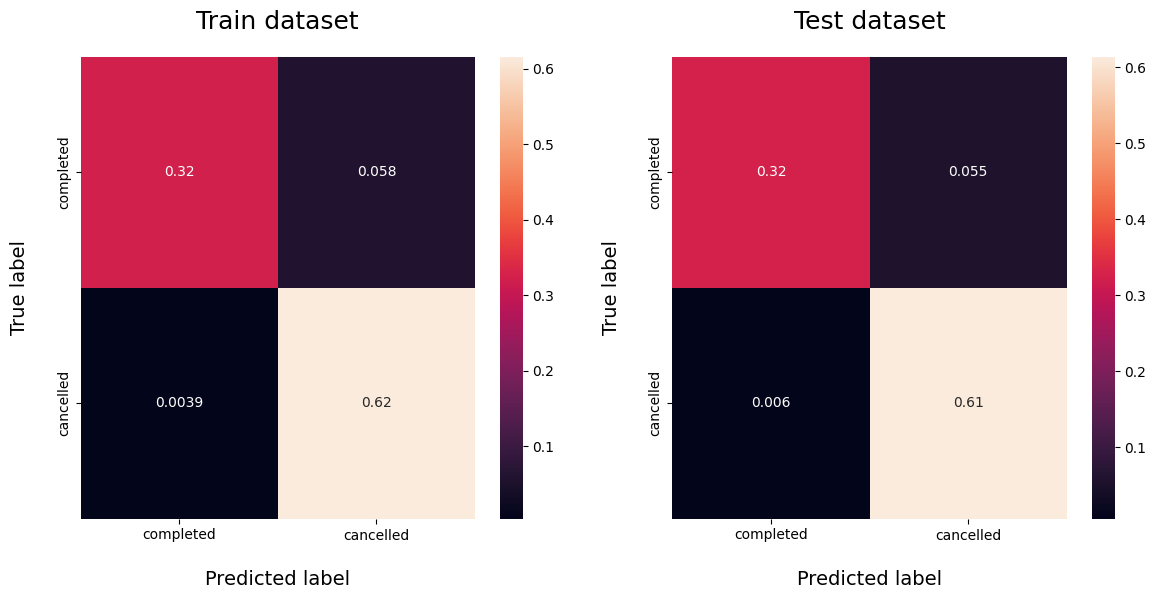

In [8]:
# confusion matrix
classify_vis_obj.confusion_matrix(model,['completed','cancelled'],normalize=True)

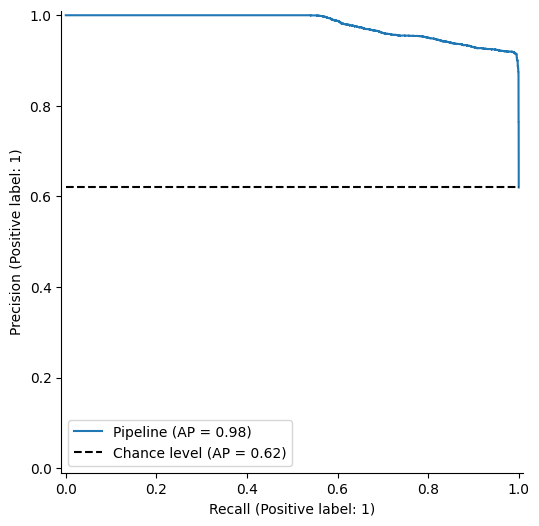

In [9]:
#precision curve
classify_vis_obj.precision_recall_curve(model)

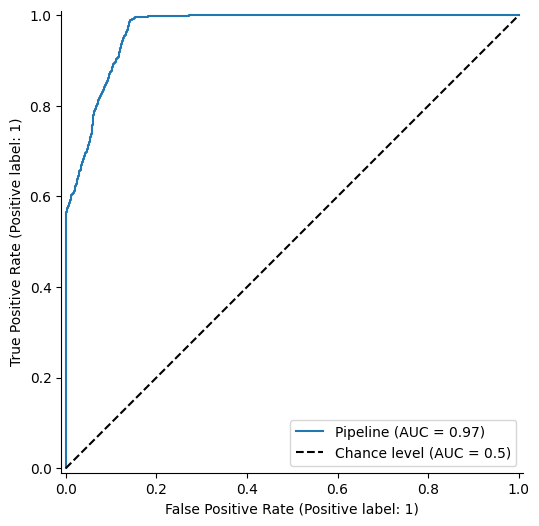

In [10]:
#ROC curve
classify_vis_obj.ROC_curve(model)

Feature Importance and Ablation Analysis

<Axes: title={'center': 'Feature Importance plot'}, xlabel='Importance', ylabel='Features'>

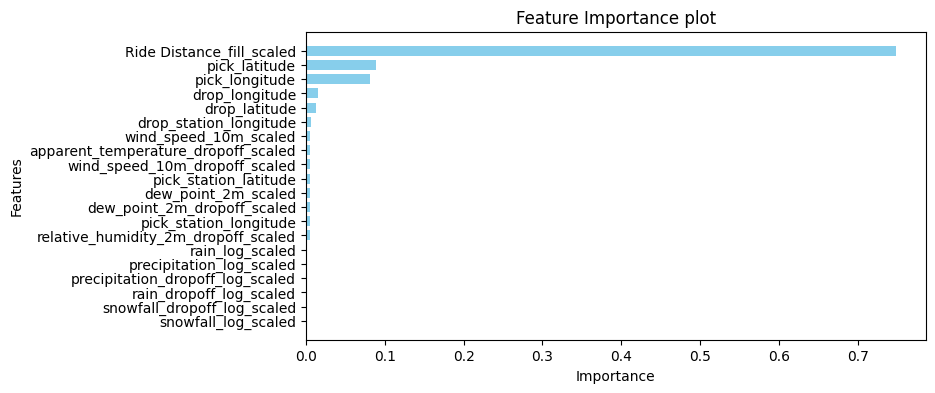

In [11]:
classify_vis_obj.feature_importance_plot(model.named_steps['clf'].feature_importances_,normalize=False,top_n=20)

In [33]:
try:
    os.makedirs(f'{base_directory}/evaluation', exist_ok=True)

    if not recalculate_evaluation:
        with open(base_directory + "/evaluation/booking_cancel_permutation_train_result.pkl", "rb") as f:
            train_permute = pickle.load(f)
        with open(base_directory + "/evaluation/booking_cancel_permutation_test_result.pkl", "rb") as f:
            test_permute = pickle.load(f)
    else:
        raise Exception('Recalculating permutation test')
except:
    train_permute,test_permute = evaluation.permutation_test(
        model,train_data,test_data,
        target_col = '_target_completed_',scorer='f1_macro',random_state=0,n_jobs=-1
    )

    with open(base_directory + "/evaluation/booking_cancel_permutation_train_result.pkl", "wb") as f:
        pickle.dump(train_permute, f)

    with open(base_directory + "/evaluation/booking_cancel_permutation_test_result.pkl", "wb") as f:
        pickle.dump(test_permute, f)

<Axes: title={'center': 'Permutation importance on train data'}, xlabel='Decrease in metric score'>

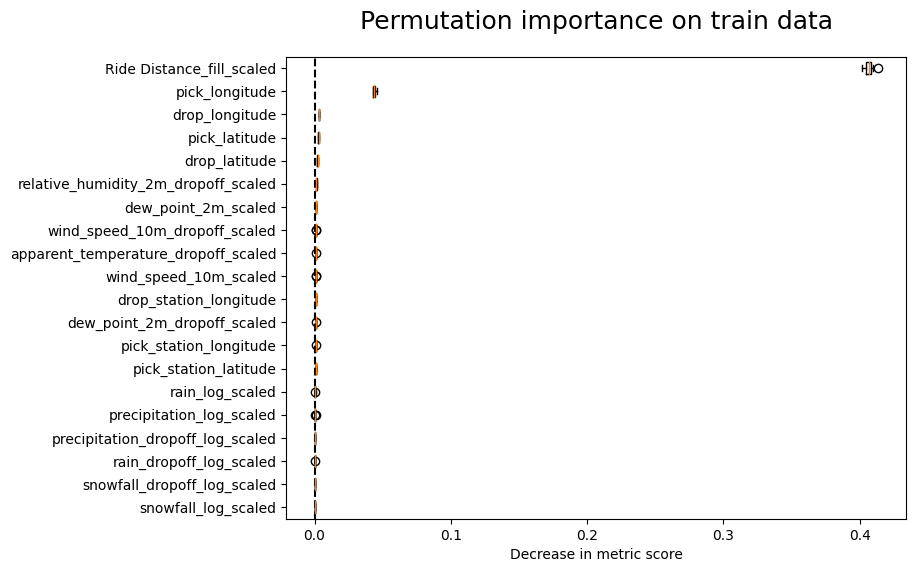

In [34]:
classify_vis_obj.permutation_importance_plot(train_permute,figsize=(8,6),title='Permutation importance on train data')

<Axes: title={'center': 'Permutation importance on test data'}, xlabel='Decrease in metric score'>

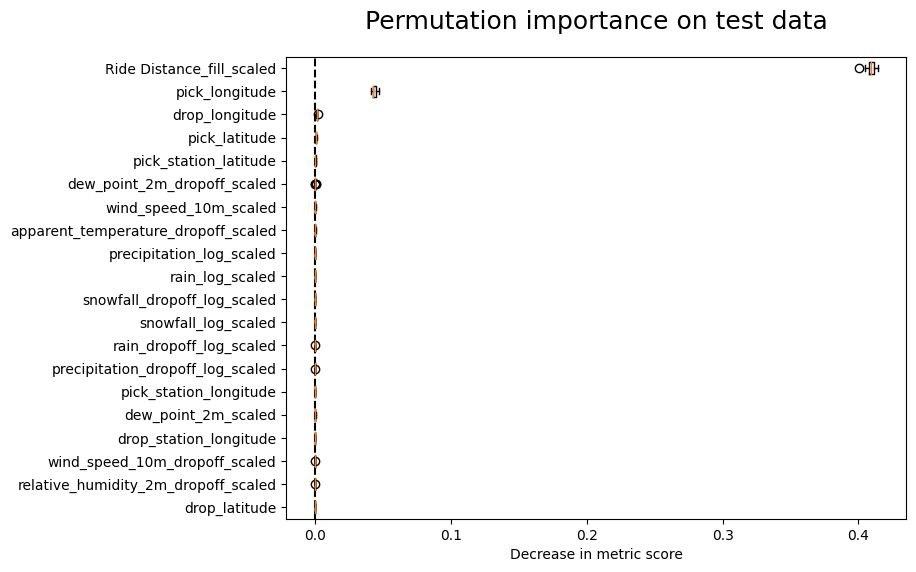

In [24]:
classify_vis_obj.permutation_importance_plot(test_permute,figsize=(8,6),title='Permutation importance on test data')

In [ ]:
try:
    os.makedirs(f'{base_directory}/evaluation', exist_ok=True)
    if not recalculate_evaluation:
        score_array = np.load(base_directory + '/evaluation/booking_cancel_ablation_test.npy')
        eval_df = pd.read_csv(base_directory + '/evaluation/booking_cancel_ablation_test.csv')
    else:
        raise Exception('Recalculating ablation test')
except:
    remove_features = ['pick_latitude',
                   'pick_longitude',
                   'Ride Distance_fill_scaled',
                    ['pick_latitude','Ride Distance_fill_scaled','pick_longitude']
                    ]

    score_array,eval_df = evaluation.ablation_test(
        model,
        train_data = train_data,
        test_data = test_data,
        target_col = '_target_completed_',
        scorer=make_scorer(f1_score,average='macro'),
        remove_features = remove_features,
        n_jobs=-1
    )

    np.save(base_directory + '/evaluation/booking_cancel_ablation_test.npy',score_array)
    eval_df.to_csv(base_directory + '/evaluation/booking_cancel_ablation_test.csv',index=False)

eval_df.head()

,remove_features,score_mean,score_std,score_test
0,none,0.927641,0.005231,0.932731
1,pick_latitude,0.927506,0.005434,0.932512
2,pick_longitude,0.926389,0.005001,0.931450
3,Ride Distance_fill_scaled,0.680867,0.008507,0.685772
4,"['pick_latitude', 'Ride Distance_fill_scaled',...",0.505164,0.006818,0.506154


<Axes: title={'center': 'Ablation test'}, xlabel='f1 score'>

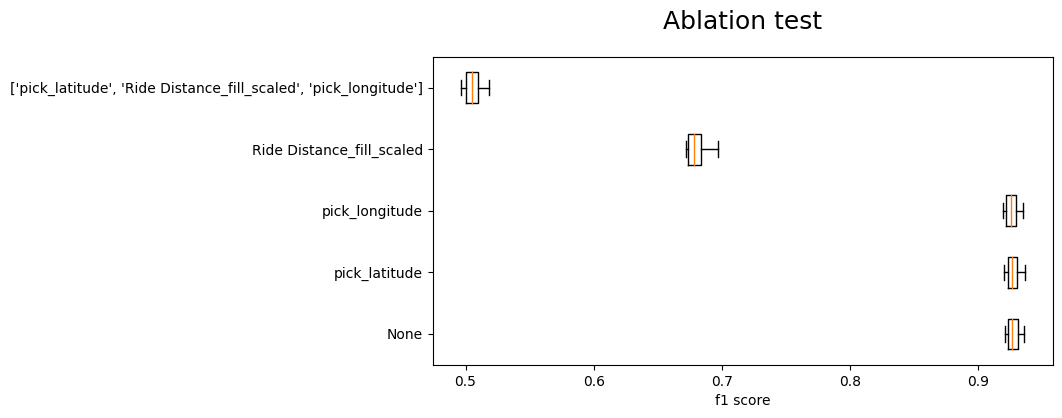

In [32]:
# Ablation test plot
classify_vis_obj.box_plot(score_array.T,labels=['None'] + remove_features,title='Ablation test',xlabel='f1 score')

Sensivity analysis

In [ ]:
try:
    os.makedirs(f'{base_directory}/evaluation', exist_ok=True)
    if not recalculate_evaluation:
        eval_df = pd.read_csv(base_directory + '/evaluation/booking_cancel_sensivity_test.csv')
    else:
        raise Exception('Recalculating sensivity test')
except:
    grids = {
        'clf__n_estimators':np.linspace(100,1000,10).astype(int),
        'clf__max_depth':np.linspace(1,11,11).astype(int)
    }
    eval_df = evaluation.supervised_sensivity_test(
        model,train_data,
        target_col='_target_completed_',
        param_grid=grids,
        scoring = 'f1_macro',
        verbose=0,
        n_jobs=-1
    )
    eval_df.to_csv(base_directory + '/evaluation/booking_cancel_sensivity_test.csv',index=False)
eval_df.head()

,clf__max_depth,clf__n_estimators,f1_macro,f1_macro_std
0,1,50,0.767163,0.007506
1,1,100,0.751017,0.007651
2,1,150,0.751030,0.007852
3,1,200,0.751513,0.007534
4,1,250,0.751458,0.007537


In [17]:
plot_1_cond = eval_df.clf__max_depth.unique()[1]
plot_2_cond = eval_df.clf__n_estimators.unique()[2]
classify_vis_obj.sensivity_plot(eval_df,
               'f1_macro',
               param1 = ('clf__n_estimators','clf__max_depth',plot_1_cond),
               param2 = ('clf__max_depth','clf__n_estimators',plot_2_cond),
               subplot_titles = [
                   f'Sensivity vs. n_estimators (with max_depth={plot_1_cond})',
                   f'Sensivity vs. max_depth (with n_estimators={plot_2_cond})',
                   None
               ]
               )

Learning curve

In [ ]:
try:
    os.makedirs(f'{base_directory}/evaluation', exist_ok=True)
    if not recalculate_evaluation:
        result_df = pd.read_csv(base_directory + '/evaluation/booking_cancel_learning_curve.csv')
    else:
        raise Exception('Recalculating learning curve')
except:
    _,_,result_df = evaluation.learning_curve_test(
        model,train_data,
        target_col='_target_completed_',
        sample_range=np.logspace(3,6,30).astype(int),
        scorer = make_scorer(f1_score,average='macro'),
        n_jobs=-1
    )

    result_df.to_csv(base_directory + '/evaluation/booking_cancel_learning_curve.csv',index=False)

result_df.head(5)

,n_sample,score_mean,score_std
0,1000,0.897081,0.031911
1,2000,0.913329,0.009403
2,3000,0.925391,0.017142
3,4000,0.925287,0.016306
4,5000,0.927794,0.014382


<Axes: title={'center': 'Learning curve analysis'}, xlabel='No. of training records', ylabel='F1 macro score'>

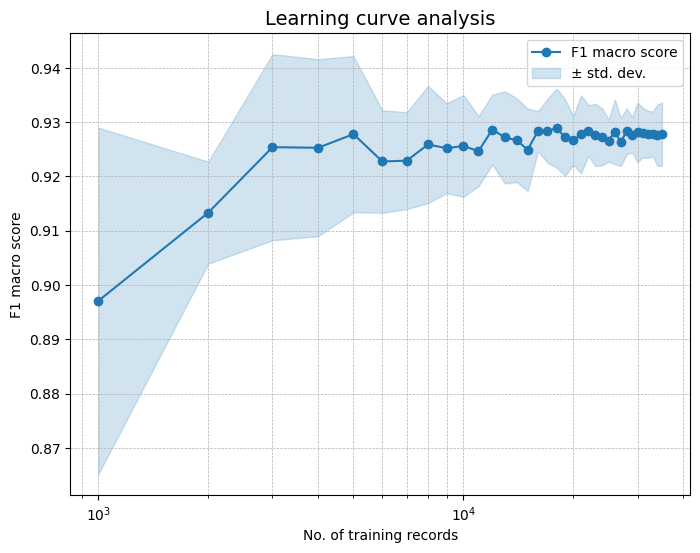

In [ ]:
# Learning curve plot

classify_vis_obj.learning_curve_plot(
    np.logspace(3,6,30).astype(int),
    result_df.score_mean,
    result_df.score_std,
    log_sample=True,
    metric_label='F1 macro score'
    )

Failure analysis (classification)

In [35]:
# get worst examples on False Positive and False Negative
ex_df,ex_info_df = evaluation.get_worst_examples(
    model,test_data,
    get_n=1,
    target_col='_target_completed_',
    problem_type='classification',
    get_random_err=False,
    random_state=0
)

test_shap_values,_ = evaluation.shap_analysis(
    model,
    shap.TreeExplainer,
    train_df = shap.sample(train_data,nsamples=1000), # recommended number in documentation
    test_df = shap.sample(test_data),
    target_col = '_target_completed_'
)

ex_shap_values,_ = evaluation.shap_analysis(
    model,
    shap.TreeExplainer,
    train_df = shap.sample(train_data,nsamples=1000),  # recommended number in documentation
    test_df = ex_df,
    target_col = '_target_completed_'
)
ex_info_df

,true_label,predicted_label,probability_0,probability_1
690,0,1,0.170112,0.829888
1922,0,1,0.480869,0.519131
6513,1,0,0.501849,0.498151
6971,1,0,0.927283,0.072717


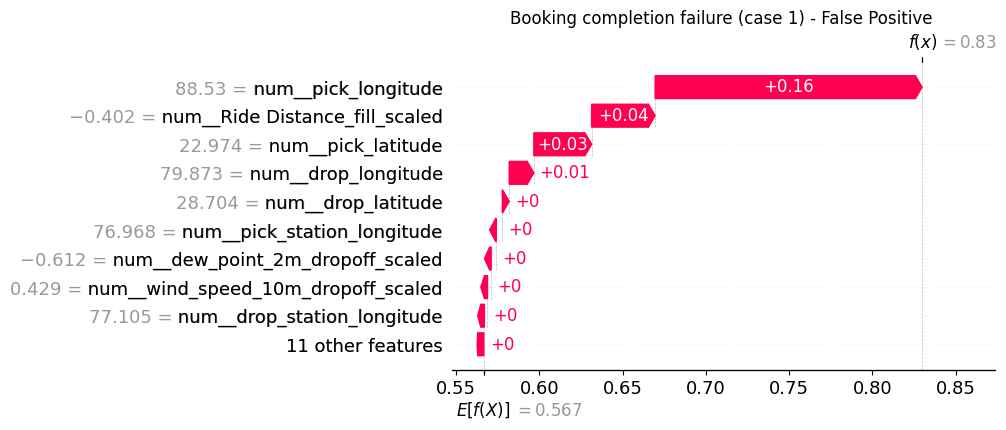

In [21]:
classify_vis_obj.waterfall_plot(
    ex_shap_values[:,:,1][0],
    title = 'Booking completion failure (case 1) - False Positive ',
    figsize=(7,4)
    )

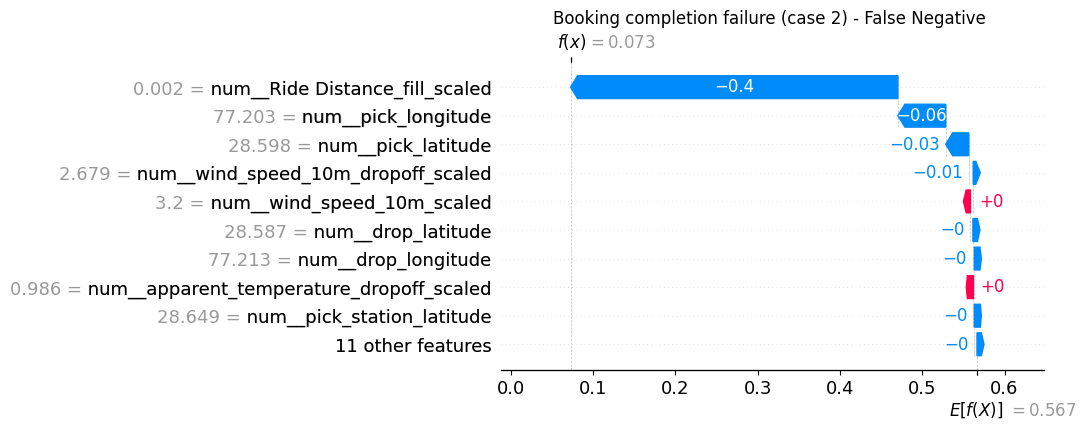

In [22]:
classify_vis_obj.waterfall_plot(
    ex_shap_values[:,:,1][-1],
    title = 'Booking completion failure (case 2) - False Negative ',
    figsize=(7,4)
    )

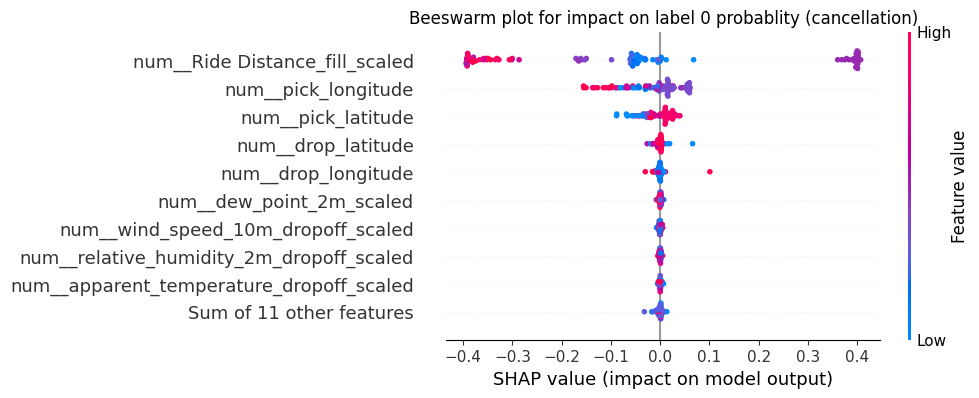

In [23]:
classify_vis_obj.beeswarm_plot(
    test_shap_values[:,:,0],
    title = 'Beeswarm plot for impact on label 0 probablity (cancellation)',
    figsize=(7,4)
    )

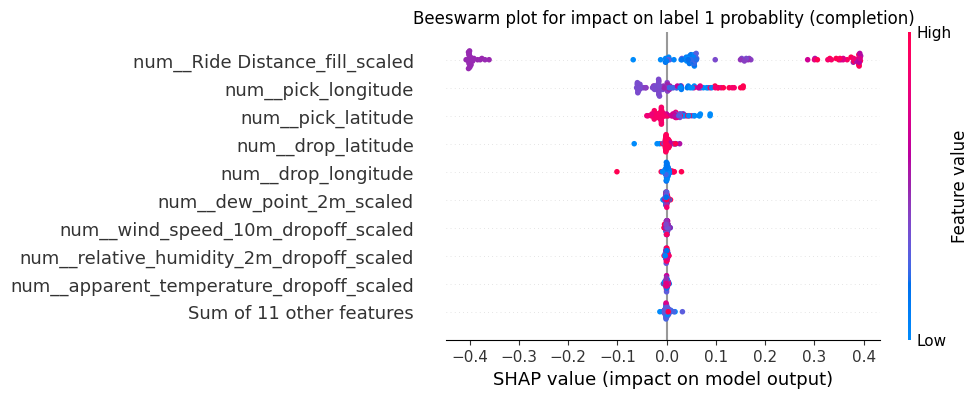

In [24]:
classify_vis_obj.beeswarm_plot(
    test_shap_values[:,:,1],
    title = 'Beeswarm plot for impact on label 1 probablity (completion)',
    figsize=(7,4)
    )